In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
from sklearn.neighbors import NearestNeighbors
from deap import base, creator, tools, algorithms
import torch
from torch_geometric.data import Data
from torch_geometric.nn import RGCNConv
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

C:\Users\TEST\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
features_weekly = pd.read_csv('features_weekly.csv')
features_weekly.head()

,user,week_start,week_number,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,...,z_http_avg_requests_per_day,z_http_upload_ratio,z_http_download_ratio,z_http_off_hours_ratio,z_http_suspicious_ratio,psycho_ocean_risk_score,ldap_zscore_departure,users_activity_not_main_pc_ratio,users_post_departure_activity,users_pre_departure_ratio
0,AAB0162,2010-01-04,1,0.222222,0.000000,0.0,0.000000,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
1,AAB0162,2010-01-11,2,0.166667,0.000000,0.0,0.011111,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
2,AAB0162,2010-01-18,3,0.229630,0.000000,0.0,0.022222,0.0,0.0,45.00,...,0.000000,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0
3,AAB0162,2010-01-25,4,0.216374,0.000000,0.0,0.023392,0.0,0.0,42.75,...,-0.342791,0.0,0.0,0.0,-0.005614,0.062937,0.27574,0.0,0.0,0.0
4,AAB0162,2010-02-01,5,0.208333,0.009259,0.0,0.023148,0.0,0.5,43.20,...,-0.628322,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0


In [3]:
df_users = pd.read_parquet('cert_dataset/users.parquet')
df_users = df_users.rename(columns={'user_id':'user'})
df_users.head()

,employee_name,user,email,role,projects,business_unit,functional_unit,department,team,supervisor,start_date,end_date
0,Nicholas Fletcher Pruitt,NFP2441,Nicholas.Fletcher.Pruitt@dtaa.com,ITAdmin,None,1,1 - Adminstration,5 - Security,8 - ElectronicSecurity,Madison Charissa Malone,2009-12-01 00:00:00,2011-06-01
1,Abraham Dante Rodgers,ADR1517,Abraham.Dante.Rodgers@dtaa.com,ProductionLineWorker,None,1,5 - Manufacturing_Commercial,3 - Assembly,4 - AssemblyDept,Mark William Horne,2009-12-01 00:00:00,2011-06-01
2,Medge Wilma Blackburn,MWB4000,Medge.Wilma.Blackburn@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,14 - AssemblyDept,Hillary Zenaida Adkins,2009-12-01 00:00:00,2011-06-01
3,Meghan Laurel Salazar,MLS2856,Meghan.Laurel.Salazar@dtaa.com,ProductionLineWorker,None,1,6 - Manufacturing_Government,3 - Assembly,8 - AssemblyDept,Demetria Sage Melendez,2009-12-01 00:00:00,2011-06-01
4,Beau Todd Romero,BTR2026,Beau.Todd.Romero@dtaa.com,MechanicalEngineer,None,1,3 - ResearchAndEngineering_Government_Domestic,4 - Engineering,16 - TestAndEvalualtion,Elijah Valentine Fuentes,2009-12-01 00:00:00,2011-06-01


In [4]:
df = features_weekly.merge(df_users[['user','supervisor']],on='user',how='left')
df.reset_index(drop=True)
df.head()

,user,week_start,week_number,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,...,z_http_upload_ratio,z_http_download_ratio,z_http_off_hours_ratio,z_http_suspicious_ratio,psycho_ocean_risk_score,ldap_zscore_departure,users_activity_not_main_pc_ratio,users_post_departure_activity,users_pre_departure_ratio,supervisor
0,AAB0162,2010-01-04,1,0.222222,0.000000,0.0,0.000000,0.0,0.0,45.00,...,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0,Jeanette Macey Simpson
1,AAB0162,2010-01-11,2,0.166667,0.000000,0.0,0.011111,0.0,0.0,45.00,...,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0,Jeanette Macey Simpson
2,AAB0162,2010-01-18,3,0.229630,0.000000,0.0,0.022222,0.0,0.0,45.00,...,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0,Jeanette Macey Simpson
3,AAB0162,2010-01-25,4,0.216374,0.000000,0.0,0.023392,0.0,0.0,42.75,...,0.0,0.0,0.0,-0.005614,0.062937,0.27574,0.0,0.0,0.0,Jeanette Macey Simpson
4,AAB0162,2010-02-01,5,0.208333,0.009259,0.0,0.023148,0.0,0.5,43.20,...,0.0,0.0,0.0,0.000000,0.062937,0.27574,0.0,0.0,0.0,Jeanette Macey Simpson


In [5]:
df['node_id'] = df.index

meta_cols = ['user', 'week_start', 'supervisor', 'node_id','week_number']  
feature_cols = [c for c in df.columns if c not in meta_cols]

df_sorted = df.sort_values(['user', 'week_number']).copy()
delta_cols = []
for col in feature_cols:
    delta = df_sorted.groupby('user')[col].diff().fillna(0)
    df_sorted[f'delta_{col}'] = delta
    delta_cols.append(f'delta_{col}')

df = df_sorted.sort_index()
feature_cols = feature_cols + delta_cols


print(f"Nombre de nœuds : {len(df)}")
print(f"Nombre de features : {len(feature_cols)}")

Nombre de nœuds : 284061
Nombre de features : 166


In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols].values)

In [7]:
# Construction des arêtes temporelles
w = 2
edges_temp = []

for user, group in df.groupby('user'):
    group_sorted = group.sort_values('week_number')
    node_ids = group_sorted['node_id'].values
    weeks = group_sorted['week_number'].values
    
    for i in range(len(node_ids)):
        for j in range(i+1, len(node_ids)):
            if abs(weeks[j] - weeks[i]) <= w:
                edges_temp.append((node_ids[i], node_ids[j]))
                edges_temp.append((node_ids[j], node_ids[i]))  
            else:
                break  

edges_temp = np.array(edges_temp).T  
print(f"Nombre d'arêtes temporelles : {edges_temp.shape[1]}")

Nombre d'arêtes temporelles : 1112244


In [8]:
# Construction des arêtes de pairs (même superviseur)
edges_peer = []

df_with_sup = df[df['supervisor'].notna()]

for (sup,week), group in df_with_sup.groupby(['supervisor','week_number']):
    node_ids = group['node_id'].values
    if len(node_ids) < 2:
        continue
    
    for i in range(len(node_ids)):
        for j in range(i+1, len(node_ids)):
            edges_peer.append((node_ids[i], node_ids[j]))
            edges_peer.append((node_ids[j], node_ids[i]))  
             

edges_peer = np.array(edges_peer).T  
print(f"Nombre d'arêtes de pairs : {edges_peer.shape[1]}")

Nombre d'arêtes de pairs : 5196544


In [9]:
# Construction des arêtes de k-NN (k users plus proches)
k = 10
edges_knn = []

for week, group in df.groupby('week_number'):
    node_ids = group['node_id'].values
    
    X_week = X[node_ids]

    nn_model = NearestNeighbors(n_neighbors = k+1,metric='cosine')

    nn_model.fit(X_week) 

    _, neighbor_positions = nn_model.kneighbors(X_week)

    for i in range(len(node_ids)):
        source_node = node_ids[i]
        for pos in neighbor_positions[i,1:]:
            target_node = node_ids[pos]
            edges_knn.append((source_node,target_node))

             
edges_knn = np.array(edges_knn).T  
print(f"Nombre d'arêtes k-NN : {edges_knn.shape[1]}")

Nombre d'arêtes k-NN : 2840610


In [10]:
# Rendre les arêtes symétriques par union
edges_set = set()
for i in range(edges_knn.shape[1]):
    src, dst = edges_knn[0, i], edges_knn[1, i]
    edges_set.add((src, dst))
    edges_set.add((dst, src))

edges_knn = np.array(list(edges_set)).T
print(f"Nombre d'arêtes k-NN après symétrisation : {edges_knn.shape[1]}")

Nombre d'arêtes k-NN après symétrisation : 4176318


In [11]:
# Création du graphe

edge_index_temp = torch.tensor(edges_temp, dtype=torch.long)
edge_index_peer = torch.tensor(edges_peer, dtype=torch.long)
edge_index_knn = torch.tensor(edges_knn, dtype=torch.long)

edge_index = torch.cat([edge_index_temp, edge_index_peer, edge_index_knn], dim=1)

edge_type = torch.cat([
    torch.zeros(edge_index_temp.shape[1],dtype=torch.long),
    torch.ones(edge_index_peer.shape[1],dtype=torch.long),
    torch.full((edge_index_knn.shape[1],),2,dtype=torch.long)
])

x = torch.tensor(X, dtype=torch.float)

data = Data(x=x,edge_index=edge_index,edge_type=edge_type)

data.num_relations = 3

print(data)
print(f"Nombre de nœuds : {data.num_nodes}")
print(f"Nombre d'arêtes total : {data.num_edges}")
print(f"Répartition : temp={(edge_type==0).sum()}, peer={(edge_type==1).sum()}, knn={(edge_type==2).sum()}")

Data(x=[284061, 166], edge_index=[2, 10485106], edge_type=[10485106], num_relations=3)
Nombre de nœuds : 284061
Nombre d'arêtes total : 10485106
Répartition : temp=1112244, peer=5196544, knn=4176318


In [12]:
# Architecture du RGCN

class RGCNAutoencoder(nn.Module):
    def __init__(self,in_channels,hidden_channels,out_channels,num_relations):
        super().__init__()

        self.conv1 = RGCNConv(in_channels,hidden_channels,num_relations,num_bases=2)
        self.conv2 = RGCNConv(hidden_channels,out_channels,num_relations,num_bases=2)

        self.decoder = nn.Sequential(
            nn.Linear(out_channels,hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels,in_channels)
        )

        self.dropout = nn.Dropout(p=0.2)

    def encode(self,x,edge_index,edge_type):
        h = self.conv1(x,edge_index,edge_type)
        h = F.relu(h)
        h = self.dropout(h)
        z = self.conv2(h,edge_index,edge_type)
        return z

    def decode_features(self,z):
        return self.decoder(z)

    def decode_links(self,z,edge_index):
        src, dst = edge_index
        return (z[src]*z[dst]).sum(dim=-1)

    def forward(self,x,edge_index,edge_type):
        z = self.encode(x,edge_index,edge_type)
        x_hat = self.decode_features(z)
        return z, x_hat

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = RGCNAutoencoder(
    in_channels=X.shape[1],
    hidden_channels=128,
    out_channels=32,
    num_relations=3
).to(device)

data = data.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Modèle créé avec {n_params:,} paramètres")
print(model)

Modèle créé avec 101,842 paramètres
RGCNAutoencoder(
  (conv1): RGCNConv(166, 128, num_relations=3)
  (conv2): RGCNConv(128, 32, num_relations=3)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=166, bias=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
)


In [14]:
all_positive_edges = data.edge_index
num_nodes = data.num_nodes
num_pos_edges = all_positive_edges.shape[1]

print(f"Pool d'arêtes positives : {num_pos_edges:,}")

Pool d'arêtes positives : 10,485,106


In [15]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3, weight_decay=1e-5)

num_epochs = 1000
alpha = 0.3 
num_neg_samples = 16384 

In [16]:
model.train()
losses_history = {'total': [], 'recon': [], 'link': []}

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    z, x_hat = model(data.x, data.edge_index, data.edge_type)
    
    loss_recon = F.mse_loss(x_hat, data.x)
    
    pos_idx = torch.randint(0, num_pos_edges, (num_neg_samples,), device=device)
    pos_edges = all_positive_edges[:, pos_idx] 

    neg_src = torch.randint(0, num_nodes, (num_neg_samples,), device=device)
    neg_dst = torch.randint(0, num_nodes, (num_neg_samples,), device=device)
    neg_edges = torch.stack([neg_src, neg_dst], dim=0)
    
    pos_scores = model.decode_links(z, pos_edges)
    neg_scores = model.decode_links(z, neg_edges)
    
    pos_labels = torch.ones_like(pos_scores)
    neg_labels = torch.zeros_like(neg_scores)
    
    loss_link = F.binary_cross_entropy_with_logits(
        torch.cat([pos_scores, neg_scores]),
        torch.cat([pos_labels, neg_labels])
    )
    
    loss = alpha * loss_recon + (1 - alpha) * loss_link
    
    loss.backward()
    optimizer.step()
    
    losses_history['total'].append(loss.item())
    losses_history['recon'].append(loss_recon.item())
    losses_history['link'].append(loss_link.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss total: {loss.item():.4f} | "
              f"Recon: {loss_recon.item():.4f} | Link: {loss_link.item():.4f}")

print("\nEntraînement terminé.")

Epoch   0 | Loss total: 8.4610 | Recon: 1.0144 | Link: 11.6524
Epoch  10 | Loss total: 2.1461 | Recon: 0.8532 | Link: 2.7002
Epoch  20 | Loss total: 1.5985 | Recon: 0.8146 | Link: 1.9345
Epoch  30 | Loss total: 1.2564 | Recon: 0.7972 | Link: 1.4531
Epoch  40 | Loss total: 1.1191 | Recon: 0.7878 | Link: 1.2610
Epoch  50 | Loss total: 1.0036 | Recon: 0.7787 | Link: 1.1000
Epoch  60 | Loss total: 0.9250 | Recon: 0.7713 | Link: 0.9908
Epoch  70 | Loss total: 0.8791 | Recon: 0.7634 | Link: 0.9287
Epoch  80 | Loss total: 0.8249 | Recon: 0.7569 | Link: 0.8540
Epoch  90 | Loss total: 0.7954 | Recon: 0.7494 | Link: 0.8152
Epoch 100 | Loss total: 0.7804 | Recon: 0.7423 | Link: 0.7967
Epoch 110 | Loss total: 0.7444 | Recon: 0.7350 | Link: 0.7484
Epoch 120 | Loss total: 0.7120 | Recon: 0.7281 | Link: 0.7051
Epoch 130 | Loss total: 0.7004 | Recon: 0.7202 | Link: 0.6919
Epoch 140 | Loss total: 0.6900 | Recon: 0.7132 | Link: 0.6801
Epoch 150 | Loss total: 0.6719 | Recon: 0.7061 | Link: 0.6572
Epoch 1

In [17]:
model.eval()
with torch.no_grad():
    z_final = model.encode(data.x, data.edge_index, data.edge_type)

Z = z_final.cpu().numpy()
print(f"Shape des embeddings : {Z.shape}")
print(f"Statistiques des embeddings :")
print(f"  Mean : {Z.mean():.4f}")
print(f"  Std  : {Z.std():.4f}")
print(f"  Min  : {Z.min():.4f}")
print(f"  Max  : {Z.max():.4f}")

Shape des embeddings : (284061, 32)
Statistiques des embeddings :
  Mean : -0.0002
  Std  : 0.4063
  Min  : -47.2492
  Max  : 67.8189


In [18]:
iforest = IsolationForest(
    n_estimators=5000,
    max_samples=8192,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)

iforest.fit(Z)

anomaly_scores = -iforest.score_samples(Z)
print(f"Shape des scores : {anomaly_scores.shape}")
print(f"Distribution des scores :")
print(f"  Min  : {anomaly_scores.min():.4f}")
print(f"  Max  : {anomaly_scores.max():.4f}")
print(f"  Mean : {anomaly_scores.mean():.4f}")

Shape des scores : (284061,)
Distribution des scores :
  Min  : 0.3268
  Max  : 0.8591
  Mean : 0.3530


In [19]:
insider_weeks_df = pd.read_csv('cert_dataset/insiders/threat_weeks.csv')

insider_node_ids = []
for _, row in insider_weeks_df.iterrows():
    matching = df[(df['user'] == row['user']) & (df['week_start'] == row['week_start'])]
    if len(matching) > 0:
        insider_node_ids.append(matching['node_id'].values[0])

insider_node_ids = np.array(insider_node_ids)
print(f"Nombre de semaines insiders identifiées : {len(insider_node_ids)}")

Nombre de semaines insiders identifiées : 21


In [20]:
sorted_indices = np.argsort(-anomaly_scores)  
ranks = np.empty_like(sorted_indices)
ranks[sorted_indices] = np.arange(len(sorted_indices))

insider_ranks = ranks[insider_node_ids]
insider_scores = anomaly_scores[insider_node_ids]

ranking_table = pd.DataFrame({
    'node_id': insider_node_ids,
    'user': df.loc[insider_node_ids, 'user'].values,
    'week': df.loc[insider_node_ids, 'week_number'].values,
    'anomaly_score': insider_scores,
    'rank': insider_ranks,
    'percentile': 100 * insider_ranks / len(anomaly_scores)
}).sort_values('rank').reset_index(drop=True)

print(f"Nombre total de nœuds : {len(anomaly_scores):,}")
print(f"Nombre d'insiders : {len(insider_node_ids)}\n")
print("Ranking des semaines d'insiders (rang 0 = le plus anormal) :")
print(ranking_table.to_string(index=False))

Nombre total de nœuds : 284,061
Nombre d'insiders : 21

Ranking des semaines d'insiders (rang 0 = le plus anormal) :
 node_id    user  week  anomaly_score   rank  percentile
  211862 PLJ1771    32       0.842267      2    0.000704
    4515 ACM2278    34       0.829893      6    0.002112
    4514 ACM2278    33       0.819296     12    0.004224
  211863 PLJ1771    33       0.758626     64    0.022530
   48268 CDE1846    60       0.537703   1743    0.613601
   48275 CDE1846    67       0.388986  14220    5.005967
   48272 CDE1846    64       0.377021  19244    6.774601
   57919 CMP2946    65       0.361069  38586   13.583702
   57916 CMP2946    62       0.358147  47401   16.686909
   57917 CMP2946    63       0.357948  48134   16.944952
   57911 CMP2946    57       0.357177  51141   18.003527
   48271 CDE1846    63       0.357150  51260   18.045420
   57918 CMP2946    64       0.352556  76991   27.103685
   57912 CMP2946    58       0.352288  78964   27.798255
   57913 CMP2946    59      

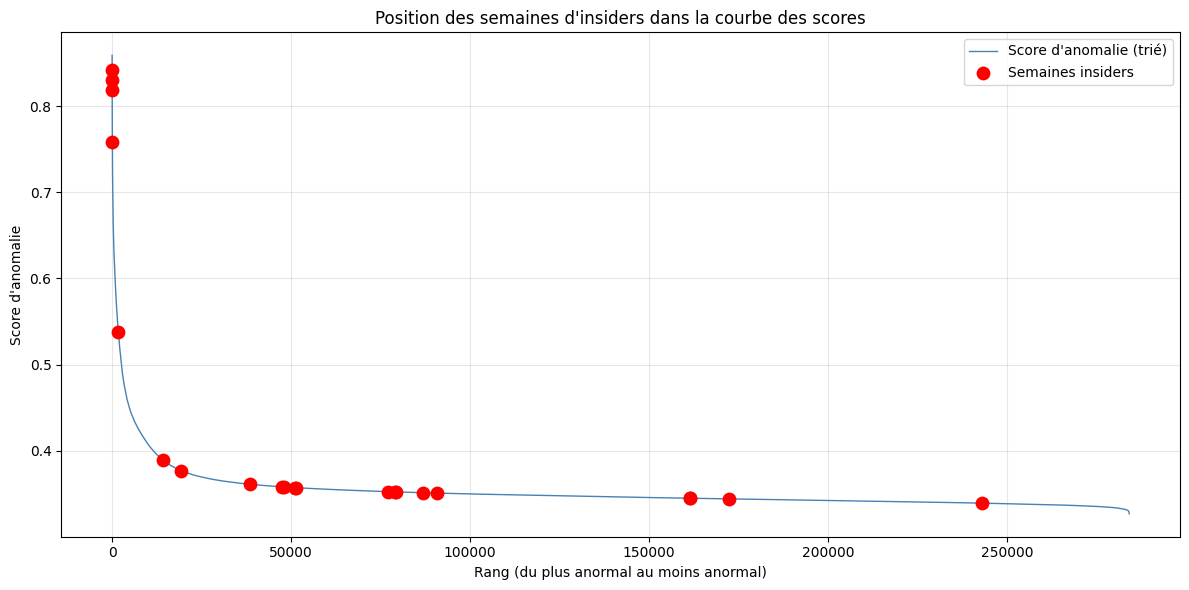

In [21]:
sorted_scores = anomaly_scores[sorted_indices]

plt.figure(figsize=(12, 6))
plt.plot(sorted_scores, color='steelblue', linewidth=1, label='Score d\'anomalie (trié)')
plt.scatter(insider_ranks, insider_scores, 
            color='red', s=80, zorder=5, label='Semaines insiders')

plt.xlabel('Rang (du plus anormal au moins anormal)')
plt.ylabel('Score d\'anomalie')
plt.title('Position des semaines d\'insiders dans la courbe des scores')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()